In [1]:
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors
from matplotlib import patches
import pyvista as pv 
import numpy as np
from matplotlib.ticker import  ScalarFormatter

def set_plt_params():
    plt.rcParams.update(plt.rcParamsDefault)
    plt.rcParams['text.usetex'] = True
    plt.rc('text.latex',preamble=r'\usepackage[utf8]{inputenc}')
    plt.rc('text.latex',preamble=r'\usepackage[russian]{babel}')
    plt.rcParams['font.size'] = 14
    plt.rcParams['font.family'] = "serif"


class MidpointNormalize(mcolors.Normalize):
    def __init__(self, vmin=None, vmax=None, midpoint=None, clip=False):
        self.midpoint = midpoint
        mcolors.Normalize.__init__(self, vmin, vmax, clip)

    def __call__(self, value, clip=None):
        v_ext = np.max([np.abs(self.vmin), np.abs(self.vmax)] )
        x, y = [-v_ext, self.midpoint, v_ext], [0, 0.5, 1]
        return np.ma.masked_array(np.interp(value, x, y))

In [3]:
file = pv.read("/home/feelsbadkot/Desktop/results/out_10000.vtk")
print(file.point_data)

pyvista DataSetAttributes
Association     : POINT
Active Scalars  : Density
Active Vectors  : Velocity
Active Texture  : None
Active Normals  : None
Contains arrays :
    Density                 float64    (5500,)              SCALARS
    Pressure                float64    (5500,)
    Energy                  float64    (5500,)
    Constant_pressure_he... float64    (5500,)
    Adiabatic_index         float64    (5500,)
    Temperature             float64    (5500,)
    Velocity                float64    (5500, 3)            VECTORS


In [43]:
line = pv.Line([0.025, 0, 0], [0.025, 2.75, 0], resolution=550)  
U_matr, V_matr, P_matr, E_matr = [], [], [], []
time_arr = 4e-6 * np.array([i for i in range(1001)])

for i in range(0, 10010, 10):
    file = f"/home/feelsbadkot/Desktop/results/out_{i}.vtk"
    mesh = pv.read(file).slice_along_line(line) 
    points = mesh.points
    sorted_indices = np.argsort(points[:, 0])
    X_sorted = points[sorted_indices, 0]
    Y_sorted = points[sorted_indices, 1]

    U_sorted = mesh.point_data["Velocity"][sorted_indices, 0]
    V_sorted = mesh.point_data["Velocity"][sorted_indices, 1]
    E_sorted = mesh.point_data["Energy"][sorted_indices]
    P_sorted = mesh.point_data["Pressure"][sorted_indices]

    U_matr.append(U_sorted)
    V_matr.append(V_sorted)
    P_matr.append(P_sorted)
    E_matr.append(E_sorted)

print(len(U_matr))

1001


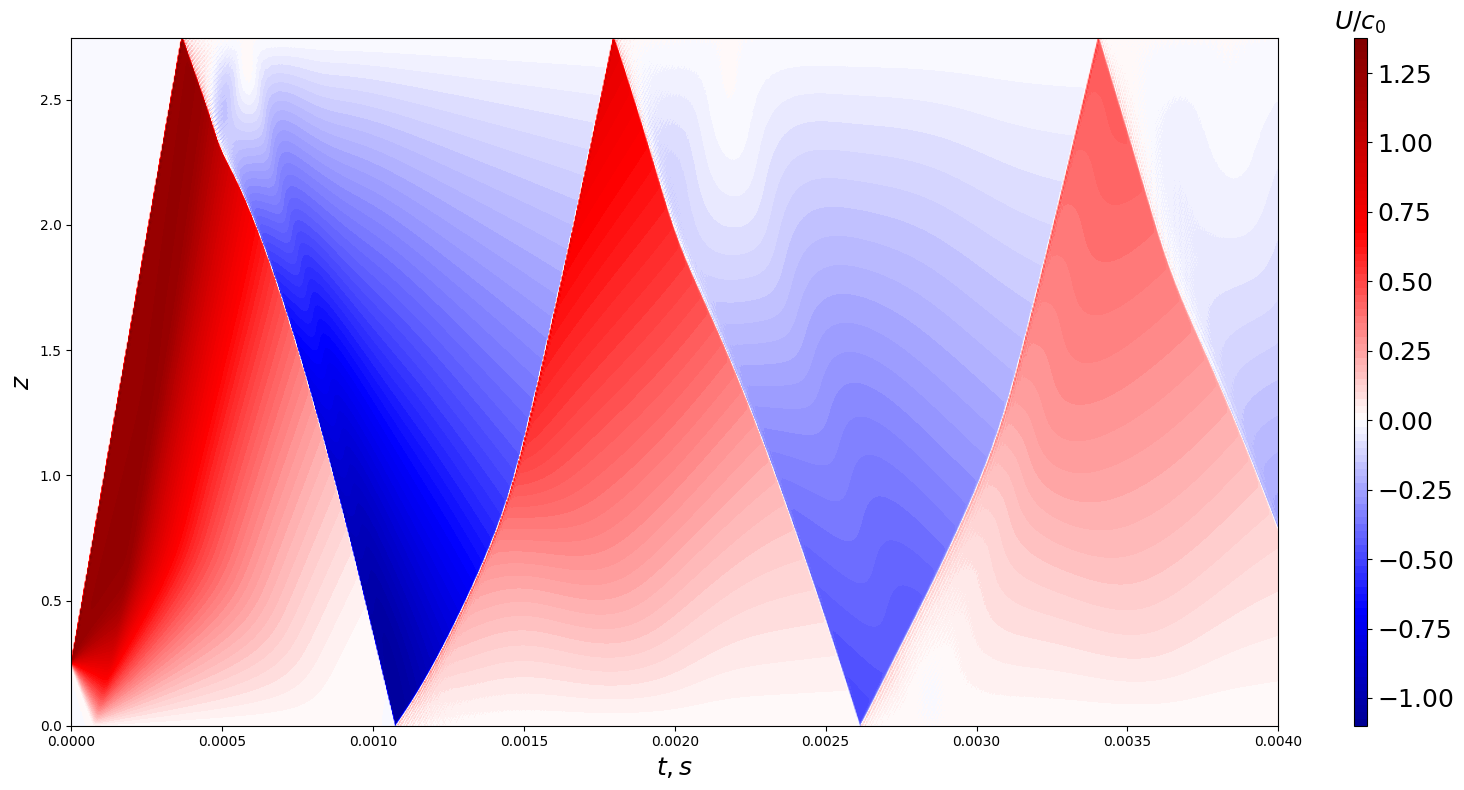

In [48]:
fig, ax = plt.subplots(figsize=(16, 8))

norm = MidpointNormalize(midpoint=0)
cf = ax.contourf(time_arr, Y_sorted, np.transpose(V_matr), levels=100, cmap="seismic", norm=norm)

ax.set_xlim(time_arr[0], time_arr[-1])
ax.set_ylim(np.min(Y_sorted[0]), np.max(Y_sorted[-1]))
ax.set_xlabel(r"$t, s$", fontsize=18, fontweight='regular')
ax.set_ylabel(r"$z$", fontsize=18, fontweight='regular')

cb = plt.colorbar(cf, orientation="vertical", aspect=50, format=ScalarFormatter(useMathText=True))
cb.formatter.set_powerlimits((0, 0))
cb.update_ticks()
cb.ax.tick_params(labelsize=18)
cb.ax.set_title(r'$U / c_0$', fontsize=18)

plt.tight_layout()
plt.savefig("U_matr.png", dpi=300)
plt.show()

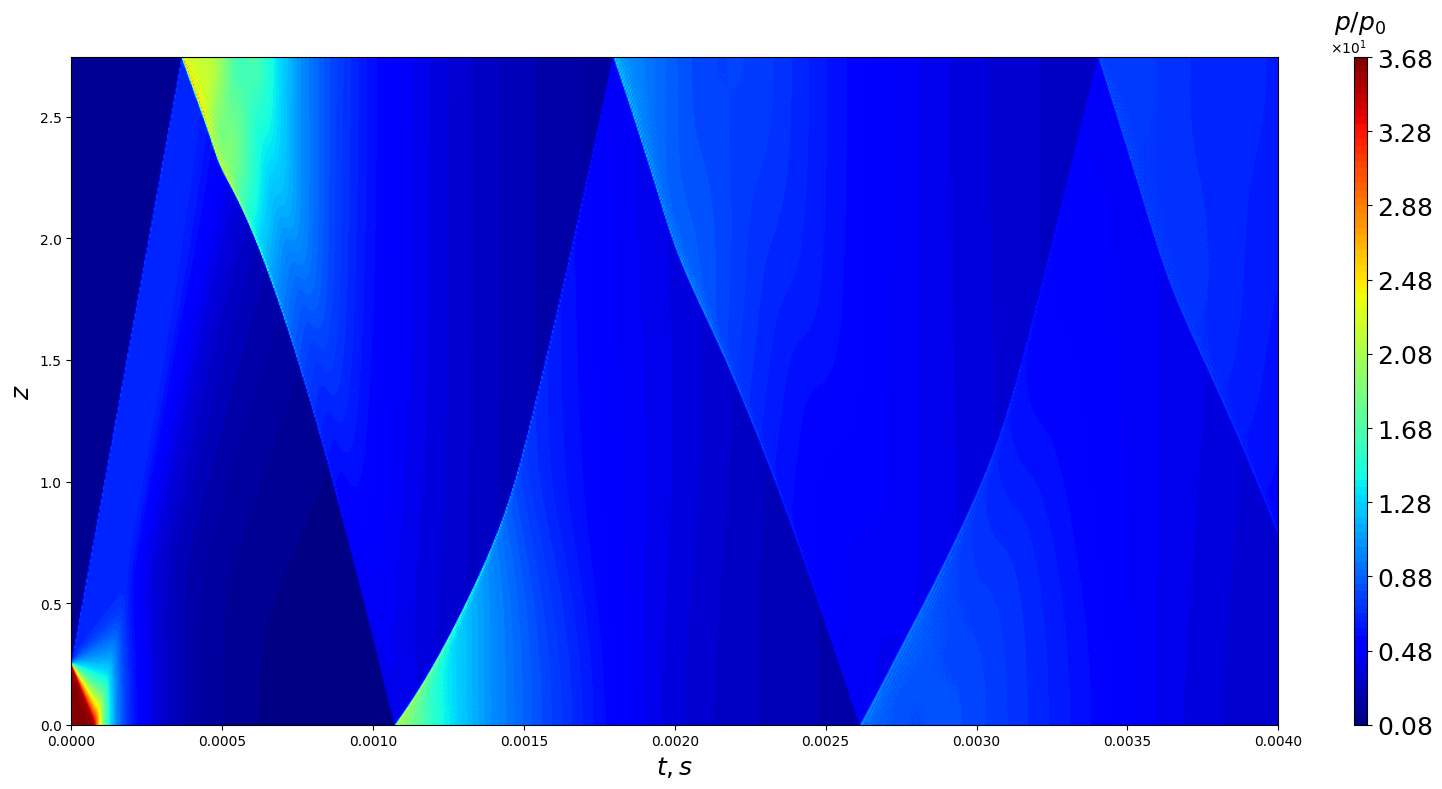

In [49]:
fig, ax = plt.subplots(figsize=(16, 8))

cf = ax.contourf(time_arr, Y_sorted, np.transpose(P_matr), levels=100, cmap="jet")

ax.set_xlim(time_arr[0], time_arr[-1])
ax.set_ylim(np.min(Y_sorted[0]), np.max(Y_sorted[-1]))
ax.set_xlabel(r"$t, s$", fontsize=18, fontweight='regular')
ax.set_ylabel(r"$z$", fontsize=18, fontweight='regular')

cb = plt.colorbar(cf, orientation="vertical", aspect=50, format=ScalarFormatter(useMathText=True))
cb.formatter.set_powerlimits((0, 0))
cb.update_ticks()
cb.ax.tick_params(labelsize=18)
cb.ax.set_title(r'$p / p_0$', fontsize=18)

plt.tight_layout()
plt.savefig("P_matr.png", dpi=300)
plt.show()

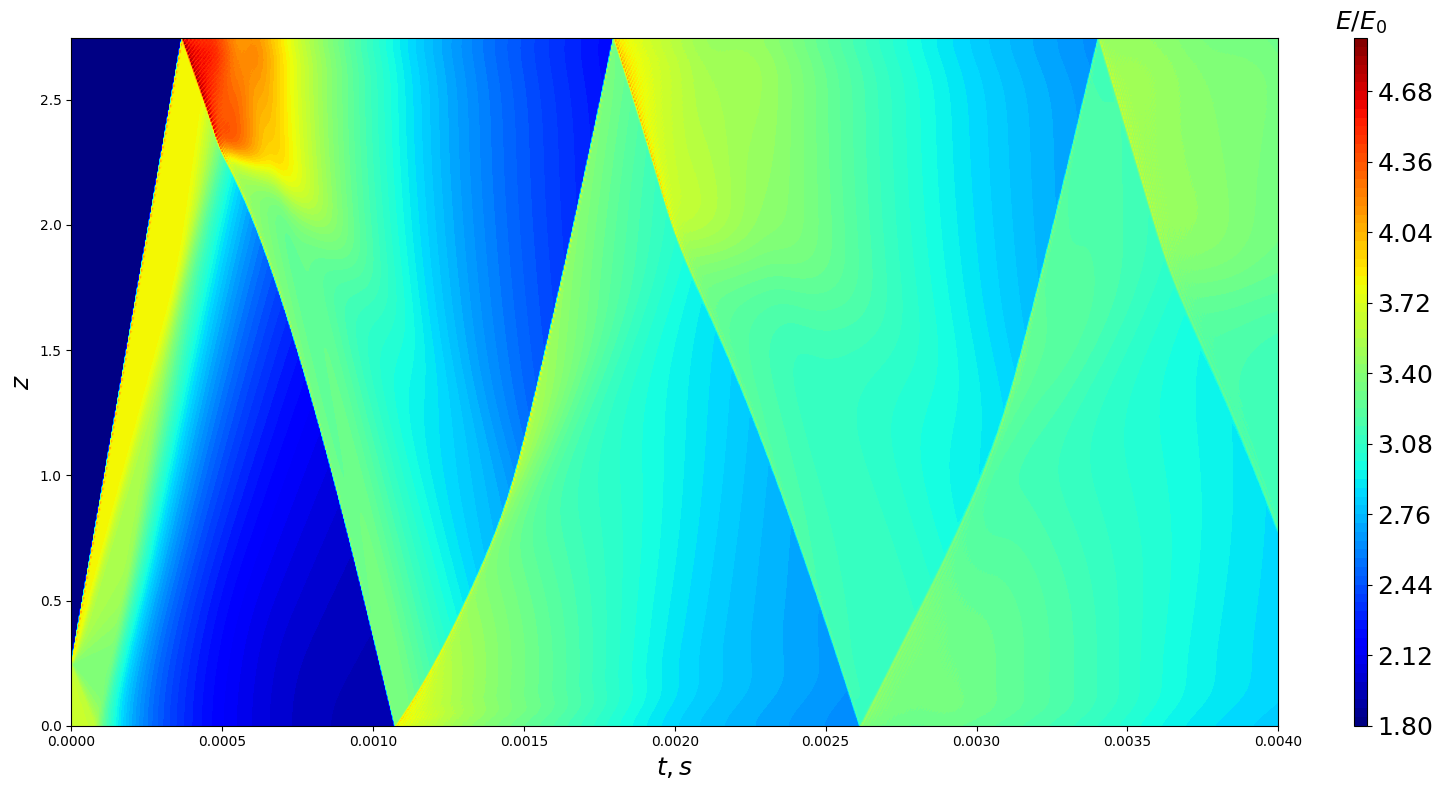

In [50]:
fig, ax = plt.subplots(figsize=(16, 8))

cf = ax.contourf(time_arr, Y_sorted, np.transpose(E_matr), levels=100, cmap="jet")

ax.set_xlim(time_arr[0], time_arr[-1])
ax.set_ylim(np.min(Y_sorted[0]), np.max(Y_sorted[-1]))
ax.set_xlabel(r"$t, s$", fontsize=18, fontweight='regular')
ax.set_ylabel(r"$z$", fontsize=18, fontweight='regular')

cb = plt.colorbar(cf, orientation="vertical", aspect=50, format=ScalarFormatter(useMathText=True))
cb.formatter.set_powerlimits((0, 0))
cb.update_ticks()
cb.ax.tick_params(labelsize=18)
cb.ax.set_title(r'$E / E_0$', fontsize=18)

plt.tight_layout()
plt.savefig("E_matr.png", dpi=300)
plt.show()

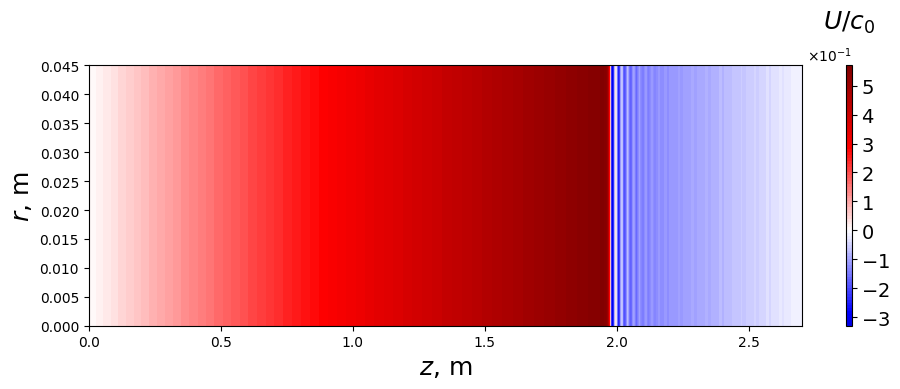

In [43]:
file = "/home/feelsbadkot/Desktop/results/out_5000.vtk"

Z = pv.read(file).points[:, 1]
R = pv.read(file).points[:, 0]

U = pv.read(file).point_data["Velocity"][:, 1]
P = pv.read(file).point_data["Pressure"]
Rho = pv.read(file).point_data["Density"]
K = pv.read(file).point_data["Adiabatic_index"]
E = pv.read(file).point_data["Energy"]
Cp = pv.read(file).point_data["Constant_pressure_heat_capacity"]

norm = MidpointNormalize(midpoint=0)
fig, ax = plt.subplots(figsize=(10, 4))
cf = ax.tricontourf(Z, R, np.transpose(U), levels=100, norm=norm, cmap="seismic")

#ax.set_aspect('equal')
ax.set_xlim(0, 2.7)
ax.set_ylim(0, 0.045)
ax.set_xlabel(r"$z$, m", fontsize=18, fontweight='regular')
ax.set_ylabel(r"$r$, m", fontsize=18, fontweight='regular')

cb = plt.colorbar(cf, orientation="vertical", aspect=50, format=ScalarFormatter(useMathText=True))
cb.formatter.set_powerlimits((0, 0))
cb.update_ticks()
cb.ax.tick_params(labelsize=14)
cb.ax.set_title(r'$U / c_0$', fontsize=18, pad=12.0)

plt.tight_layout()
plt.savefig(f"U_field", dpi=300)
plt.show()

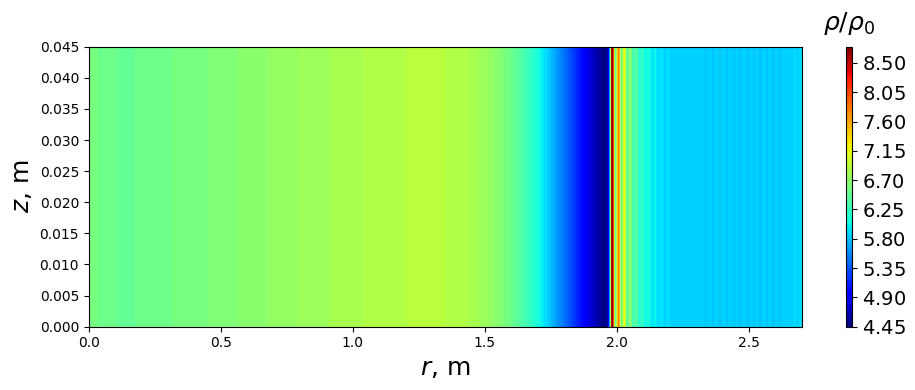

In [45]:
norm = MidpointNormalize(midpoint=0)
fig, ax = plt.subplots(figsize=(10, 4))
cf = ax.tricontourf(Z, R, np.transpose(Rho), levels=100, cmap="jet")

#ax.set_aspect('equal')
ax.set_xlim(0, 2.7)
ax.set_ylim(0, 0.045)
ax.set_xlabel(r"$r$, m", fontsize=18, fontweight='regular')
ax.set_ylabel(r"$z$, m", fontsize=18, fontweight='regular')

cb = plt.colorbar(cf, orientation="vertical", aspect=50, format=ScalarFormatter(useMathText=True))
cb.formatter.set_powerlimits((0, 0))
cb.update_ticks()
cb.ax.tick_params(labelsize=14)
cb.ax.set_title(r'$\rho / \rho_0$', fontsize=18, pad=12.0)

plt.tight_layout()
plt.savefig(f"Rho_field.png", dpi=300)
plt.show()

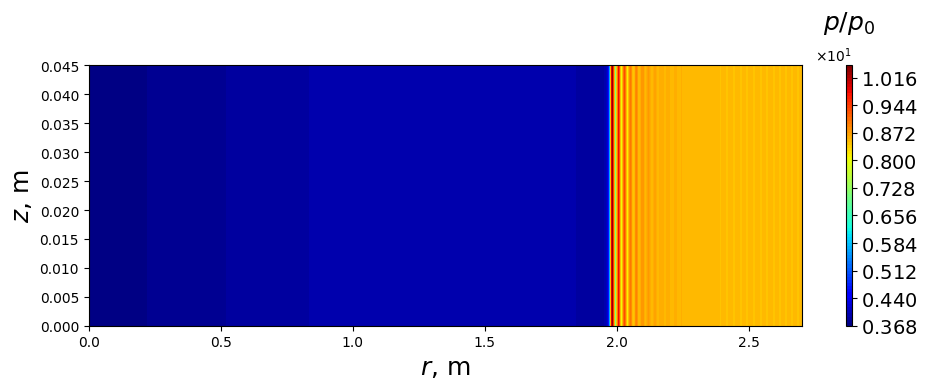

In [46]:
norm = MidpointNormalize(midpoint=0)
fig, ax = plt.subplots(figsize=(10, 4))
cf = ax.tricontourf(Z, R, np.transpose(P), levels=100, cmap="jet")

#ax.set_aspect('equal')
ax.set_xlim(0, 2.7)
ax.set_ylim(0, 0.045)
ax.set_xlabel(r"$r$, m", fontsize=18, fontweight='regular')
ax.set_ylabel(r"$z$, m", fontsize=18, fontweight='regular')

cb = plt.colorbar(cf, orientation="vertical", aspect=50, format=ScalarFormatter(useMathText=True))
cb.formatter.set_powerlimits((0, 0))
cb.update_ticks()
cb.ax.tick_params(labelsize=14)
cb.ax.set_title(r'$p / p_0$', fontsize=18, pad=12.0)

plt.tight_layout()
plt.savefig(f"P_field.png", dpi=300)
plt.show()

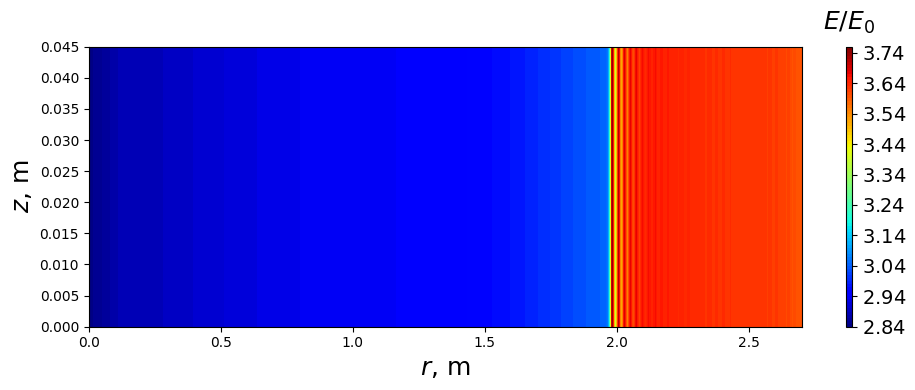

In [47]:
norm = MidpointNormalize(midpoint=0)
fig, ax = plt.subplots(figsize=(10, 4))
cf = ax.tricontourf(Z, R, np.transpose(E), levels=100, cmap="jet")

#ax.set_aspect('equal')
ax.set_xlim(0, 2.7)
ax.set_ylim(0, 0.045)
ax.set_xlabel(r"$r$, m", fontsize=18, fontweight='regular')
ax.set_ylabel(r"$z$, m", fontsize=18, fontweight='regular')

cb = plt.colorbar(cf, orientation="vertical", aspect=50, format=ScalarFormatter(useMathText=True))
cb.formatter.set_powerlimits((0, 0))
cb.update_ticks()
cb.ax.tick_params(labelsize=14)
cb.ax.set_title(r'$E / E_0$', fontsize=18, pad=12.0)

plt.tight_layout()
plt.savefig(f"E_field.png", dpi=300)
plt.show()

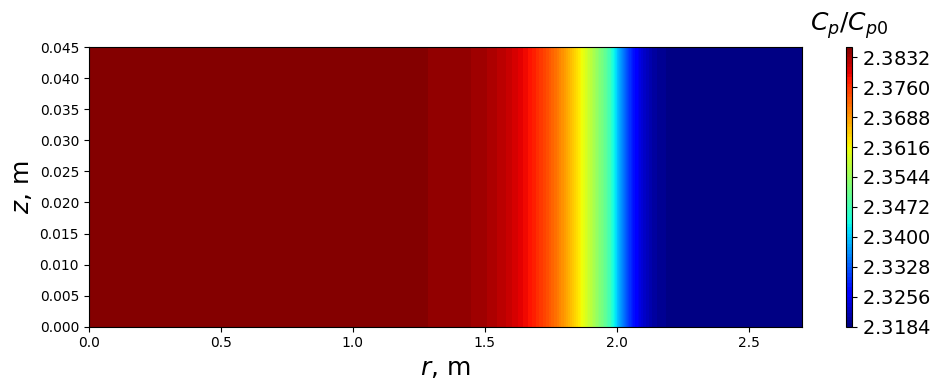

In [48]:
norm = MidpointNormalize(midpoint=0)
fig, ax = plt.subplots(figsize=(10, 4))
cf = ax.tricontourf(Z, R, np.transpose(Cp), levels=100, cmap="jet")

#ax.set_aspect('equal')
ax.set_xlim(0, 2.7)
ax.set_ylim(0, 0.045)
ax.set_xlabel(r"$r$, m", fontsize=18, fontweight='regular')
ax.set_ylabel(r"$z$, m", fontsize=18, fontweight='regular')

cb = plt.colorbar(cf, orientation="vertical", aspect=50, format=ScalarFormatter(useMathText=True))
cb.formatter.set_powerlimits((0, 0))
cb.update_ticks()
cb.ax.tick_params(labelsize=14)
cb.ax.set_title(r'$C_p / C_{p0}$', fontsize=18, pad=12.0)

plt.tight_layout()
plt.savefig(f"Cp_field.png", dpi=300)
plt.show()

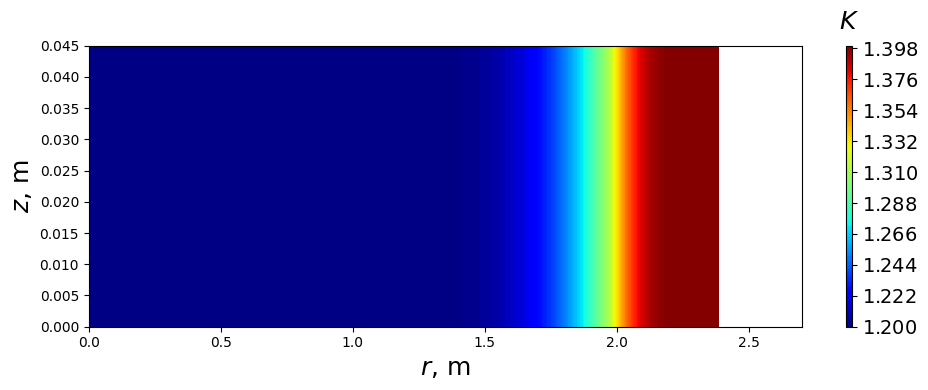

In [49]:
norm = MidpointNormalize(midpoint=0)
fig, ax = plt.subplots(figsize=(10, 4))
cf = ax.tricontourf(Z, R, np.transpose(K), levels=100, cmap="jet")

#ax.set_aspect('equal')
ax.set_xlim(0, 2.7)
ax.set_ylim(0, 0.045)
ax.set_xlabel(r"$r$, m", fontsize=18, fontweight='regular')
ax.set_ylabel(r"$z$, m", fontsize=18, fontweight='regular')

cb = plt.colorbar(cf, orientation="vertical", aspect=50, format=ScalarFormatter(useMathText=True))
cb.formatter.set_powerlimits((0, 0))
cb.update_ticks()
cb.ax.tick_params(labelsize=14)
cb.ax.set_title(r'$K$', fontsize=18, pad=12.0)

plt.tight_layout()
plt.savefig(f"K_field.png", dpi=300)
plt.show()